In [1]:
!pip install -q mtcnn opencv-python-headless tensorflow scikit-learn seaborn kagglehub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 68.2 MB/s eta 0:00:00


In [ ]:
import os, gc, cv2, json as _json, glob, shutil, zipfile, random
from pathlib import Path
from google.colab import files
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# GPU setup
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    print(f'GPU: {[g.name for g in gpus]}')
else:
    print('No GPU -- training will be slow.')
print('TensorFlow:', tf.__version__)

# Global config
IMG_SIZE   = (224, 224)   # uniform for face AND eye to match EfficientNet pretrain
BATCH_SIZE = 32
MODEL_DIR  = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)


GPU: ['/physical_device:GPU:0']
TensorFlow: 2.19.0


"" Inserting the Face and Eye Datasets + unzipping them ""

In [3]:
import os, zipfile

# Keep same variable names for lower cells
FACE_DATASET = "face_dataset"
EYE_DATASET  = "eye_dataset"

FACE_ZIP_PATH = "/content/finaset.zip"
EYE_ZIP_PATH  = "/content/mergedd_classification_dataset.zip"


def unzip_if_needed(zip_path, output_folder):
    if os.path.exists(output_folder):
        print(f"{output_folder} already exists -- skipping unzip.")
        return

    os.makedirs(output_folder, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(output_folder)

    print(f"Extracted {zip_path} -> {output_folder}")


def find_ready_dataset_root(base_dir):
    """Return the folder that contains train/valid/test, even if the zip had one nested top folder."""
    for root, dirs, files in os.walk(base_dir):
        if all(os.path.isdir(os.path.join(root, s)) for s in ["train", "valid", "test"]):
            return root
    raise FileNotFoundError(f"Could not find train/valid/test inside {base_dir}")


unzip_if_needed(FACE_ZIP_PATH, FACE_DATASET)
unzip_if_needed(EYE_ZIP_PATH, EYE_DATASET)

# If the ZIP contains face_dataset/face_dataset/train, this fixes the path automatically.
FACE_DATASET = find_ready_dataset_root(FACE_DATASET)
EYE_DATASET  = find_ready_dataset_root(EYE_DATASET)

print("Datasets ready.")
print("FACE_DATASET =", FACE_DATASET)
print("EYE_DATASET  =", EYE_DATASET)


Extracted /content/finaset.zip -> face_dataset
Extracted /content/mergedd_classification_dataset.zip -> eye_dataset
Datasets ready.
FACE_DATASET = face_dataset
EYE_DATASET  = eye_dataset/mergedd_classification_dataset


In [ ]:
# =============================================================================
# Two separate preprocessing strategies:
#
#  FACE images: detect face + crop full face region, then resize to 224x224.
#               Fallback to centre-crop if Haar cascade misses the face.
#
#  EYE images:  dataset images are full-face images, so we first detect the face
#               and crop the upper-middle face area where the eyes are located.
#               Fallback to an upper-middle crop if Haar cascade misses the face.
# =============================================================================


# Face Detector using Haar Cascade ( OpenCV )
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

# The Preprocessing Function for Face images
def preprocess_face(img_bgr):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w    = img_rgb.shape[:2]
    scale   = min(1.0, 600.0 / max(h, w))
    small   = cv2.resize(img_rgb, (int(w * scale), int(h * scale)))
    gray    = cv2.cvtColor(small, cv2.COLOR_RGB2GRAY)
    faces   = face_cascade.detectMultiScale(gray, 1.1, 5, minSize=(40, 40))

    if len(faces) > 0:
        xs, ys, ws, hs = max(faces, key=lambda box: box[2] * box[3])
        x  = max(0, int(xs / scale))
        y  = max(0, int(ys / scale))
        fw = int(ws / scale)
        fh = int(hs / scale)
        mx, my = int(fw * 0.15), int(fh * 0.20)
        crop = img_rgb[
            max(0, y - my): min(h, y + fh + my),
            max(0, x - mx): min(w, x + fw + mx)
        ]
    else:
        side = min(h, w)
        cy, cx = h // 2, w // 2
        crop = img_rgb[cy - side//2: cy + side//2, cx - side//2: cx + side//2]

    if crop.size == 0:
        crop = img_rgb

    return cv2.resize(crop, IMG_SIZE)

# The Preprocessing Function for Eye images
def preprocess_eye(img_bgr):
    """
    Eye preprocessing for FULL FACE images:
    1. Detect face.
    2. Crop upper-middle face area where the eyes usually are.
    3. Resize to IMG_SIZE.
    """
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    scale = min(1.0, 600.0 / max(h, w))
    small = cv2.resize(img_rgb, (int(w * scale), int(h * scale)))

    gray = cv2.cvtColor(small, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5, minSize=(40, 40))

    if len(faces) > 0:
        xs, ys, ws, hs = max(faces, key=lambda box: box[2] * box[3])
        x = max(0, int(xs / scale))
        y = max(0, int(ys / scale))
        fw = int(ws / scale)
        fh = int(hs / scale)

        eye_y1 = y + int(0.22 * fh)
        eye_y2 = y + int(0.55 * fh)
        eye_x1 = x + int(0.10 * fw)
        eye_x2 = x + int(0.90 * fw)

        crop = img_rgb[
            max(0, eye_y1):min(h, eye_y2),
            max(0, eye_x1):min(w, eye_x2)
        ]
    else:
        eye_y1 = int(0.25 * h)
        eye_y2 = int(0.55 * h)
        eye_x1 = int(0.15 * w)
        eye_x2 = int(0.85 * w)
        crop = img_rgb[eye_y1:eye_y2, eye_x1:eye_x2]

    if crop.size == 0:
        crop = img_rgb

    return cv2.resize(crop, IMG_SIZE)


def build_processed_dataset(src_dir, dst_dir, preprocess_fn):
    if os.path.exists(dst_dir):
        total = sum(
            len(os.listdir(os.path.join(dst_dir, sp, cl)))
            for sp in os.listdir(dst_dir) if os.path.isdir(os.path.join(dst_dir, sp))
            for cl in os.listdir(os.path.join(dst_dir, sp))
            if os.path.isdir(os.path.join(dst_dir, sp, cl))
        )
        if total > 0:
            print(f'{dst_dir} already built ({total} images). Skipping.')
            return

    for split in ['train', 'valid', 'test']:
        split_dir = os.path.join(src_dir, split)
        if not os.path.exists(split_dir):
            raise FileNotFoundError(f'Missing split folder: {split_dir}')

        classes = [c for c in os.listdir(split_dir)
                   if os.path.isdir(os.path.join(split_dir, c))]
        ok, drop = 0, 0

        for cls in classes:
            in_dir  = os.path.join(split_dir, cls)
            out_dir = os.path.join(dst_dir, split, cls)
            os.makedirs(out_dir, exist_ok=True)

            for fname in os.listdir(in_dir):
                if not fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    continue
                out_path = os.path.join(out_dir, fname)
                if os.path.exists(out_path):
                    continue

                img = cv2.imread(os.path.join(in_dir, fname))
                if img is None:
                    drop += 1
                    continue

                processed = preprocess_fn(img)
                if processed is None or processed.size == 0:
                    drop += 1
                    continue

                cv2.imwrite(out_path, cv2.cvtColor(processed, cv2.COLOR_RGB2BGR))
                ok += 1

        print(f'  {dst_dir}/{split}: {ok} saved, {drop} skipped')
        gc.collect()



"" Preprocesses Face Dataset  separetly and creates preproccessed Dataset ""

In [5]:
print('Preprocessing face images')
build_processed_dataset(FACE_DATASET, 'processed_face', preprocess_face)


Preprocessing face images
  processed_face/train: 3500 saved, 0 skipped
  processed_face/valid: 1000 saved, 0 skipped
  processed_face/test: 500 saved, 0 skipped


In [ ]:
# Frees unused memory 
gc.collect()

# Clears TensorFlow’s internal state
tf.keras.backend.clear_session()

"" Preprocesses Eye Dataset  separetly and creates preproccessed Dataset ""

In [7]:
print('\nPreprocessing eye images')
build_processed_dataset(EYE_DATASET, 'processed_eye', preprocess_eye)

print('\nPreprocessing done.')


Preprocessing eye images
  processed_eye/train: 539 saved, 0 skipped
  processed_eye/valid: 153 saved, 0 skipped
  processed_eye/test: 80 saved, 0 skipped

Preprocessing done.


In [ ]:
# Frees unused memory 
gc.collect()

# Clears TensorFlow’s internal state
tf.keras.backend.clear_session()

In [9]:
def count_images(base):
    result = {}
    for split in ['train', 'valid', 'test']:
        p = os.path.join(base, split)
        if not os.path.exists(p): continue
        result[split] = {}
        for cls in sorted(os.listdir(p)):
            cls_path = os.path.join(p, cls)
            if os.path.isdir(cls_path):
                result[split][cls] = len(os.listdir(cls_path))
    return result

for name, base in [('FACE', 'processed_face'), ('EYE', 'processed_eye')]:
    counts = count_images(base)
    print(f'\n{name} dataset:')
    for split, classes in counts.items():
        print(f'  {split}: {classes}  total={sum(classes.values())}')



FACE dataset:
  train: {'Heart': 700, 'Oblong': 700, 'Oval': 700, 'Round': 700, 'Square': 700}  total=3500
  valid: {'Heart': 200, 'Oblong': 200, 'Oval': 200, 'Round': 200, 'Square': 200}  total=1000
  test: {'Heart': 100, 'Oblong': 100, 'Oval': 100, 'Round': 100, 'Square': 100}  total=500

EYE dataset:
  train: {'almond': 109, 'downturned': 100, 'hooded': 137, 'round': 91, 'upturned': 102}  total=539
  valid: {'almond': 31, 'downturned': 28, 'hooded': 39, 'round': 26, 'upturned': 29}  total=153
  test: {'almond': 16, 'downturned': 15, 'hooded': 21, 'round': 13, 'upturned': 15}  total=80


"" Converting class labeles into IDs ""

In [ ]:
# lets TensorFlow automatically decide the best number of parallel threads and buffering for CPU/GPU Utilization.
AUTOTUNE = tf.data.AUTOTUNE

def load_image_label(path, label, img_size):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32)
    return img, label


def make_dataset(folder, img_size, batch_size, classes, augment=False, shuffle=True):
    # Creates a mapping from class name to a numeric ID.
    cls2idx = {c: i for i, c in enumerate(classes)}

    paths, labels = [], []

    for cls in classes:
        cls_dir = os.path.join(folder, cls)

        for fname in os.listdir(cls_dir):
            if fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
                paths.append(os.path.join(cls_dir, fname))
                labels.append(cls2idx[cls])

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    # Shuffle the dataset 
    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(
        lambda p, l: load_image_label(p, l, img_size),
        num_parallel_calls=AUTOTUNE
    )
    
    # *** Augmentation Techniques ***
    if augment:
        aug_layers = keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.10),
            layers.RandomZoom(0.12),
            layers.RandomTranslation(0.08, 0.08),
            layers.RandomBrightness(0.20),
            layers.RandomContrast(0.20),
        ])

        ds = ds.map(
            lambda x, y: (aug_layers(x, training=True), y),
            num_parallel_calls=AUTOTUNE
        )

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)

    return ds, cls2idx

"" Building Separate train/valid/test setd from the preprocessed Face and Eye Datasets ""

In [ ]:
face_classes = sorted(os.listdir("processed_face/train"))
face_classes = [
    c for c in face_classes
    if os.path.isdir(os.path.join("processed_face/train", c))
]

eye_classes = sorted(os.listdir("processed_eye/train"))
eye_classes = [
    c for c in eye_classes
    if os.path.isdir(os.path.join("processed_eye/train", c))
]

# Augmentation and shuffeling is applied only to the training set
face_train_ds, face_cls2idx = make_dataset(
    "processed_face/train",
    IMG_SIZE,
    BATCH_SIZE,
    classes=face_classes,
    augment=True,
    shuffle=True
)

face_val_ds, _ = make_dataset(
    "processed_face/valid",
    IMG_SIZE,
    BATCH_SIZE,
    classes=face_classes,
    augment=False,
    shuffle=False
)

face_test_ds, _ = make_dataset(
    "processed_face/test",
    IMG_SIZE,
    BATCH_SIZE,
    classes=face_classes,
    augment=False,
    shuffle=False
)

# Augmentation and shuffeling is applied only to the training set
eye_train_ds, eye_cls2idx = make_dataset(
    "processed_eye/train",
    IMG_SIZE,
    BATCH_SIZE,
    classes=eye_classes,
    augment=True,
    shuffle=True
)

eye_val_ds, _ = make_dataset(
    "processed_eye/valid",
    IMG_SIZE,
    BATCH_SIZE,
    classes=eye_classes,
    augment=False,
    shuffle=False
)

eye_test_ds, _ = make_dataset(
    "processed_eye/test",
    IMG_SIZE,
    BATCH_SIZE,
    classes=eye_classes,
    augment=False,
    shuffle=False
)


face_idx2label = {v: k for k, v in face_cls2idx.items()}
eye_idx2label  = {v: k for k, v in eye_cls2idx.items()}

print("Face classes:", face_cls2idx)
print("Eye classes:", eye_cls2idx)
print("tf.data pipelines ready.")

Face classes: {'Heart': 0, 'Oblong': 1, 'Oval': 2, 'Round': 3, 'Square': 4}
Eye classes: {'almond': 0, 'downturned': 1, 'hooded': 2, 'round': 3, 'upturned': 4}
tf.data pipelines ready.


"" Class Weights Criteria "" (For class imbalance issue) Helps preventing the model from being biased towards the majority class

In [12]:
def get_class_weights(folder, classes):
    counts = []

    for cls in classes:
        cls_dir = os.path.join(folder, cls)
        counts.append(len(os.listdir(cls_dir)))

    labels = np.repeat(np.arange(len(classes)), counts)

    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(len(classes)),
        y=labels
    )

    cw = {i: float(w) for i, w in enumerate(weights)}

    print(f"  Classes: {classes}")
    print(f"  Counts : {counts}")
    print(f"  Weights: {[round(w, 3) for w in weights]}")

    return cw


print("Face class weights:")
face_class_weights = get_class_weights(
    "processed_face/train",
    face_classes
)

print("\nEye class weights:")
eye_class_weights = get_class_weights(
    "processed_eye/train",
    eye_classes
)

Face class weights:
  Classes: ['Heart', 'Oblong', 'Oval', 'Round', 'Square']
  Counts : [700, 700, 700, 700, 700]
  Weights: [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]

Eye class weights:
  Classes: ['almond', 'downturned', 'hooded', 'round', 'upturned']
  Counts : [109, 100, 137, 91, 102]
  Weights: [np.float64(0.989), np.float64(1.078), np.float64(0.787), np.float64(1.185), np.float64(1.057)]


"" Building the EffecientNetB0 Model Architecture ""

In [ ]:
def build_efficientnet_model(n_classes, img_size=224, dropout=0.40, l2_reg=1e-4):
    tf.keras.backend.clear_session()
    gc.collect()

    inputs = keras.Input(shape=(img_size, img_size, 3))
    x      = tf.keras.applications.efficientnet.preprocess_input(inputs)

    # the feature extractor layer ( Backbone )
    base = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_tensor=x,
        pooling=None,
    )
    base.trainable = False  # Stage 1: freeze the backbone

    # the classification head ( custom )
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(512, kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout * 0.6)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs, out)
    return model, base


def compile_model(model, lr):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy'],
    )
    return model


print('build_efficientnet_model defined.')
print('Backbone: EfficientNetB0 (ImageNet pretrained)')
print('Head: GAP -> Dense(512, BN, ReLU, DO) -> Dense(256, BN, ReLU, DO) -> Softmax')
print('Strategy: three-stage fine-tuning: head -> top-30 -> full')


build_efficientnet_model defined.
Backbone: EfficientNetB0 (ImageNet pretrained)
Head: GAP -> Dense(512, BN, ReLU, DO) -> Dense(256, BN, ReLU, DO) -> Softmax
Strategy: three-stage fine-tuning: head -> top-30 -> full


In [ ]:
def three_stage_train(
    model, base_model,
    train_ds, val_ds,
    class_weights,
    ckpt_path,
    stage1_epochs=15,
    stage2_epochs=20,
    stage3_epochs=25,
    stage1_lr=3e-3,
    stage2_lr=5e-5,
    stage3_lr=1e-5,
):
    # Save best weights during training, then save the final best full model to ckpt_path.
    weights_path = ckpt_path.replace('.keras', '.weights.h5')

    def cbs(patience=8, min_lr=1e-8):
        return [
            ModelCheckpoint(
                weights_path,
                save_best_only=True,
                save_weights_only=True,
                monitor='val_accuracy',
                mode='max',
                verbose=0
            ),
            EarlyStopping(
                monitor='val_accuracy',
                patience=patience,
                restore_best_weights=True,
                verbose=1
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=4,
                min_lr=min_lr,
                verbose=1
            ),
        ]

    # Stage 1: head only
    print('\n' + '='*55)
    print('STAGE 1: Head-only training (base frozen)')
    print('='*55)
    base_model.trainable = False
    compile_model(model, stage1_lr)
    hist1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=stage1_epochs,
        class_weight=class_weights,
        callbacks=cbs(patience=6),
        verbose=1,
    )
    print(f'  Best stage-1 val_acc: {max(hist1.history["val_accuracy"]):.4f}')

    # Stage 2: unfreeze top-30 layers
    print('\n' + '='*55)
    print('STAGE 2: Top-30 layers unfrozen')
    print('='*55)

    # Train all the layers of the backbone including the top layers
    base_model.trainable = True

    # Except the early 30 layers of the backbone (which are more general and less likely to overfit)
    for layer in base_model.layers[:-30]:
        layer.trainable = False
        
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
    compile_model(model, stage2_lr)
    hist2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=stage1_epochs + stage2_epochs,
        initial_epoch=len(hist1.history['loss']),
        class_weight=class_weights,
        callbacks=cbs(patience=8),
        verbose=1,
    )
    print(f'  Best stage-2 val_acc: {max(hist2.history["val_accuracy"]):.4f}')

    # Stage 3: full network
    print('\n' + '='*55)
    print('STAGE 3: Full network (very low LR)')
    print('='*55)
    for layer in base_model.layers:
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True
    compile_model(model, stage3_lr)
    total_epochs = stage1_epochs + stage2_epochs + stage3_epochs
    hist3 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=total_epochs,
        initial_epoch=len(hist1.history['loss']) + len(hist2.history['loss']),
        class_weight=class_weights,
        callbacks=cbs(patience=10, min_lr=1e-9),
        verbose=1,
    )
    print(f'  Best stage-3 val_acc: {max(hist3.history["val_accuracy"]):.4f}')

    if os.path.exists(weights_path):
        model.load_weights(weights_path)

    model.save(ckpt_path)
    print(f'Best full model saved -> {ckpt_path}')
    print(f'Best weights also saved -> {weights_path}')
    return hist1, hist2, hist3

print('three_stage_train defined.')


three_stage_train defined.


"" The 3-stage Face Model Training ""

In [16]:
print('Building face model...')

face_model, face_base = build_efficientnet_model(
    n_classes=len(face_classes),
    img_size=IMG_SIZE[0],
    dropout=0.40
)

FACE_CKPT = os.path.join(MODEL_DIR, 'face_efficientnet.keras')

face_h1, face_h2, face_h3 = three_stage_train(
    face_model,
    face_base,
    face_train_ds,
    face_val_ds,
    face_class_weights,
    FACE_CKPT,
    stage1_epochs=15,
    stage2_epochs=20,
    stage3_epochs=25,
    stage1_lr=3e-3,
    stage2_lr=5e-5,
    stage3_lr=1e-5,
)

# Save full face model
face_model.save(FACE_CKPT)
print("Face model saved to:", FACE_CKPT)

# Download face model to your PC
from google.colab import files
files.download(FACE_CKPT)

# Remove face model from RAM
del face_model
del face_base
tf.keras.backend.clear_session()
gc.collect()

print("Face model removed from RAM.")

Building face model...

STAGE 1: Head-only training (base frozen)
Epoch 1/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 118s 827ms/step - accuracy: 0.3057 - loss: 1.8632 - val_accuracy: 0.3760 - val_loss: 1.6648 - learning_rate: 0.0030
Epoch 2/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 56s 506ms/step - accuracy: 0.3757 - loss: 1.6321 - val_accuracy: 0.3980 - val_loss: 1.5697 - learning_rate: 0.0030
Epoch 3/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 57s 520ms/step - accuracy: 0.4131 - loss: 1.5714 - val_accuracy: 0.4640 - val_loss: 1.4861 - learning_rate: 0.0030
Epoch 4/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 80s 503ms/step - accuracy: 0.4300 - loss: 1.5362 - val_accuracy: 0.4870 - val_loss: 1.4477 - learning_rate: 0.0030
Epoch 5/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 55s 495ms/step - accuracy: 0.4509 - loss: 1.5066 - val_accuracy: 0.4470 - val_loss: 1.5677 - learning_rate: 0.0030
Epoch 6/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 81s 487ms/step - accuracy: 0.4789 - loss: 1.4801 - val_accuracy: 0.4690 - val_loss: 1.4794 - learning_rate: 0.0030
Epo

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Face model removed from RAM.


"" The 3-stage Eye Model Training ""

In [ ]:

print('Building eye model...')

eye_model, eye_base = build_efficientnet_model(
    n_classes=len(eye_classes),
    img_size=IMG_SIZE[0],
    dropout=0.45
)

EYE_CKPT = os.path.join(MODEL_DIR, 'eye_efficientnet.keras')

eye_h1, eye_h2, eye_h3 = three_stage_train(
    eye_model,
    eye_base,
    eye_train_ds,
    eye_val_ds,
    eye_class_weights,
    EYE_CKPT,
    stage1_epochs=15,
    stage2_epochs=20,
    stage3_epochs=25,
    stage1_lr=3e-3,
    stage2_lr=4e-5,
    stage3_lr=8e-6,
)

# Save full eye model
eye_model.save(EYE_CKPT)
print("Eye model saved to:", EYE_CKPT)

# Download eye model to your PC
files.download(EYE_CKPT)

# Remove eye model from RAM
del eye_model
del eye_base
tf.keras.backend.clear_session()
gc.collect()

print("Eye model removed from RAM.")

Building eye model...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

STAGE 1: Head-only training (base frozen)
Epoch 1/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.2913 - loss: 1.9960 - val_accuracy: 0.2614 - val_loss: 1.8263 - learning_rate: 0.0030
Epoch 2/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 548ms/step - accuracy: 0.3265 - loss: 1.8107 - val_accuracy: 0.3137 - val_loss: 2.1354 - learning_rate: 0.0030
Epoch 3/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 527ms/step - accuracy: 0.3544 - loss: 1.6388 - val_accuracy: 0.2288 - val_loss: 2.0780 - learning_rate: 0.0030
Epoch 4/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 521ms/step - accuracy: 0.3878 - loss: 1.5989 - val_accuracy: 0.3007 - val_loss: 1.8552 - learning_rate: 0.0030
Epoch 5/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.4004 - loss: 1.6030
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.001500000013038516.
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 509ms/step - accuracy: 0.4341 - loss: 1.5263 - val_accuracy: 0.3725 - val_loss: 1.90

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Eye model removed from RAM.


In [ ]:
# =============================================================================
# Save trained models + class-label files, then download as one ZIP.
# Run this cell AFTER both face and eye training cells finish.
# =============================================================================

FACE_MODEL_PATH = FACE_CKPT
EYE_MODEL_PATH  = EYE_CKPT

FACE_CLASSES_PATH = os.path.join(MODEL_DIR, 'face_classes.txt')
EYE_CLASSES_PATH  = os.path.join(MODEL_DIR, 'eye_classes.txt')

with open(FACE_CLASSES_PATH, 'w') as f:
    f.write('\n'.join(face_classes))

with open(EYE_CLASSES_PATH, 'w') as f:
    f.write('\n'.join(eye_classes))

print('Saved:')
print(' ', FACE_MODEL_PATH)
print(' ', EYE_MODEL_PATH)
print(' ', FACE_CLASSES_PATH)
print(' ', EYE_CLASSES_PATH)

# Create one downloadable ZIP containing both models and class-label text files.
ZIP_BASE = 'trained_face_eye_models'
ZIP_PATH = shutil.make_archive(ZIP_BASE, 'zip', MODEL_DIR)

print('Download ZIP:', ZIP_PATH)
files.download(ZIP_PATH)


Saved:
  models/face_efficientnet.keras
  models/eye_efficientnet.keras
  models/face_classes.txt
  models/eye_classes.txt
Download ZIP: /content/trained_face_eye_models.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

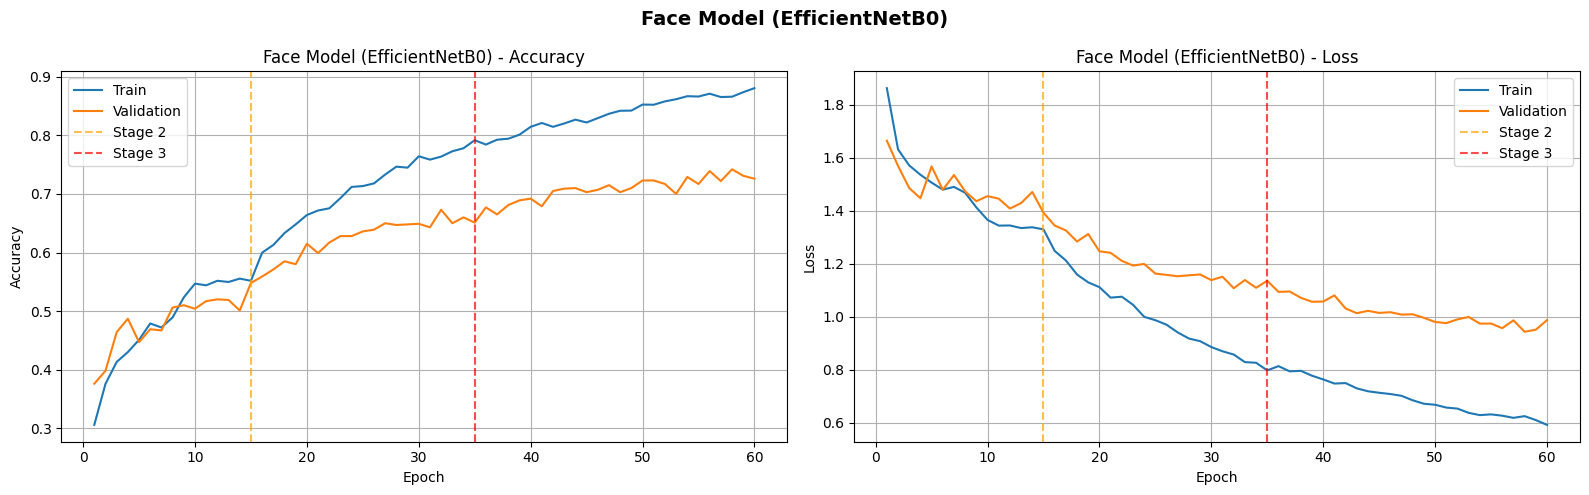

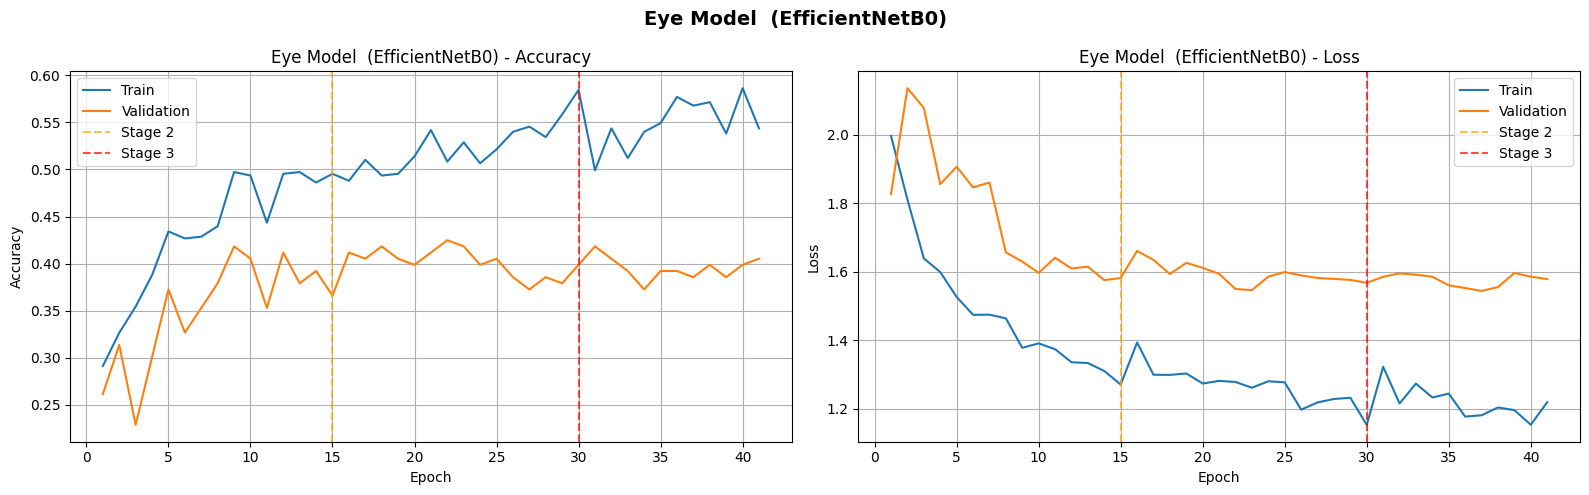

In [18]:
def plot_all_stages(h1, h2, h3, title='Model'):
    acc   = h1.history['accuracy'] + h2.history['accuracy'] + h3.history['accuracy']
    vacc  = h1.history['val_accuracy'] + h2.history['val_accuracy'] + h3.history['val_accuracy']
    loss  = h1.history['loss'] + h2.history['loss'] + h3.history['loss']
    vloss = h1.history['val_loss'] + h2.history['val_loss'] + h3.history['val_loss']
    s1e   = len(h1.history['loss'])
    s2e   = s1e + len(h2.history['loss'])
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for ax, tr, va, lbl in [(axes[0], acc, vacc, 'Accuracy'), (axes[1], loss, vloss, 'Loss')]:
        x = range(1, len(tr) + 1)
        ax.plot(x, tr, label='Train')
        ax.plot(x, va, label='Validation')
        ax.axvline(s1e, color='orange', ls='--', alpha=0.7, label='Stage 2')
        ax.axvline(s2e, color='red',    ls='--', alpha=0.7, label='Stage 3')
        ax.set_xlabel('Epoch'); ax.set_ylabel(lbl)
        ax.set_title(f'{title} - {lbl}')
        ax.legend(); ax.grid(True)
    plt.tight_layout(); plt.show()

plot_all_stages(face_h1, face_h2, face_h3, 'Face Model (EfficientNetB0)')
plot_all_stages(eye_h1,  eye_h2,  eye_h3,  'Eye Model  (EfficientNetB0)')


In [19]:
print("Reloading trained models for evaluation...")

face_model = tf.keras.models.load_model(FACE_CKPT)
eye_model = tf.keras.models.load_model(EYE_CKPT)

print("Models reloaded.")

Reloading trained models for evaluation...
Models reloaded.



Face Model - NORMAL Evaluation
Accuracy       : 0.7320 (73.20%)
Macro F1-score : 0.7314

Classification Report:
              precision    recall  f1-score   support

       Heart       0.70      0.73      0.72       100
      Oblong       0.77      0.81      0.79       100
        Oval       0.65      0.62      0.64       100
       Round       0.75      0.77      0.76       100
      Square       0.78      0.73      0.75       100

    accuracy                           0.73       500
   macro avg       0.73      0.73      0.73       500
weighted avg       0.73      0.73      0.73       500


Raw Confusion Matrix - Face Model - Normal Confusion Matrix:
[[73  6  9  6  6]
 [ 4 81  6  4  5]
 [16  8 62  8  6]
 [ 4  4 11 77  4]
 [ 7  6  7  7 73]]


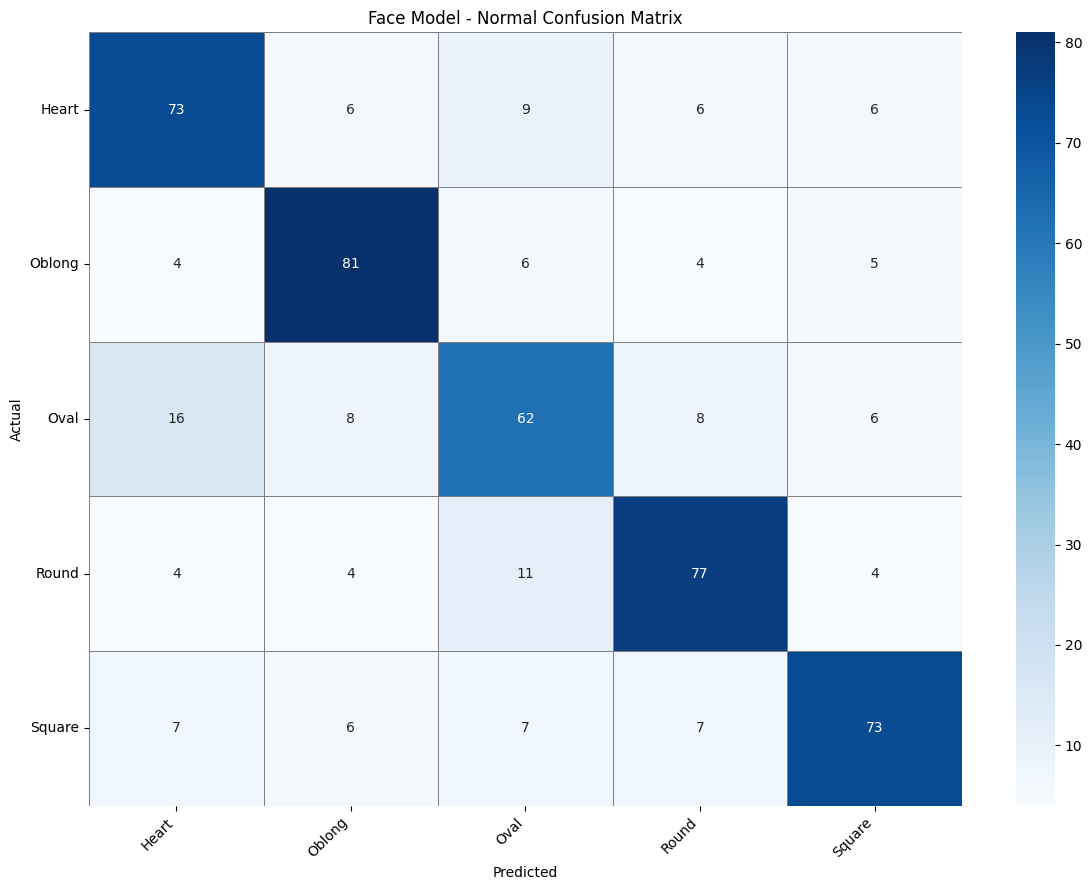


Face Model - TTA Evaluation (x5)
Accuracy       : 0.7960 (79.60%)
Macro F1-score : 0.7969

Classification Report:
              precision    recall  f1-score   support

       Heart       0.73      0.79      0.76       100
      Oblong       0.88      0.84      0.86       100
        Oval       0.73      0.74      0.73       100
       Round       0.79      0.83      0.81       100
      Square       0.88      0.78      0.83       100

    accuracy                           0.80       500
   macro avg       0.80      0.80      0.80       500
weighted avg       0.80      0.80      0.80       500


Raw Confusion Matrix - Face Model - TTA Confusion Matrix (x5):
[[79  2 11  5  3]
 [ 6 84  5  3  2]
 [12  3 74  7  4]
 [ 5  2  8 83  2]
 [ 6  5  4  7 78]]


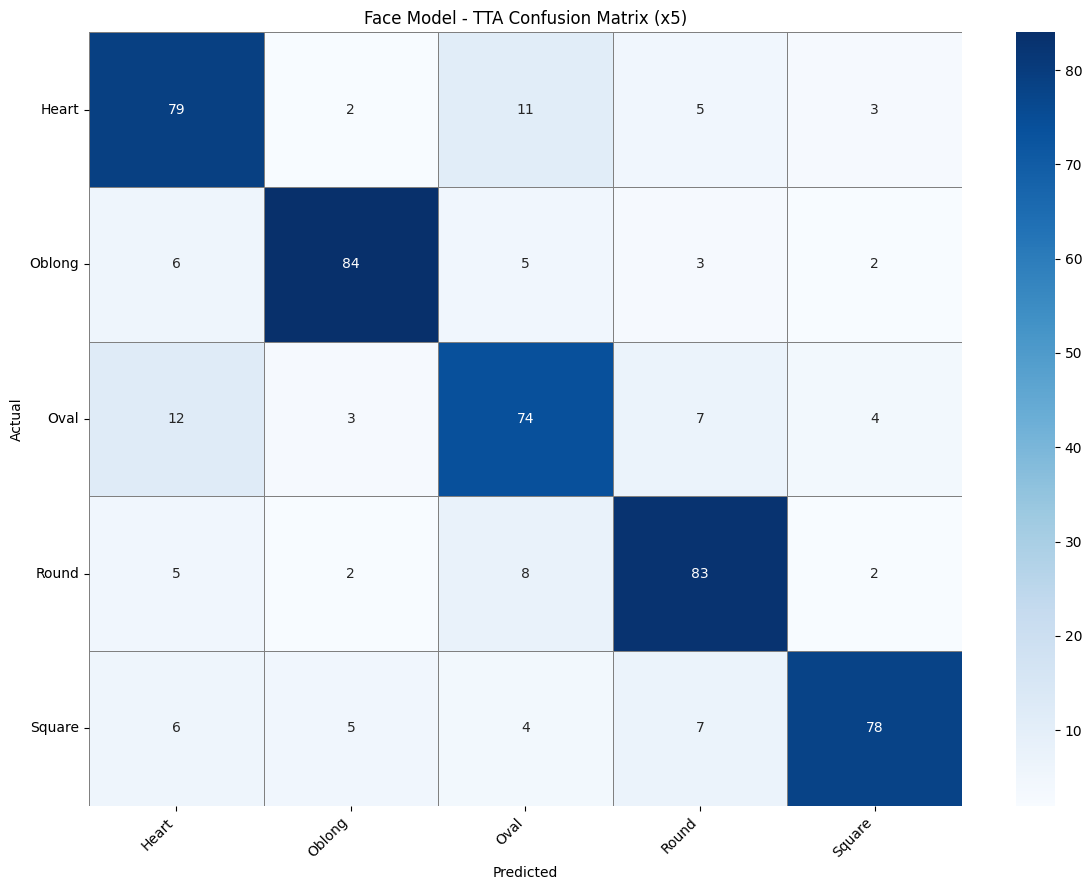


Eye Model - NORMAL Evaluation
Accuracy       : 0.4250 (42.50%)
Macro F1-score : 0.4167

Classification Report:
              precision    recall  f1-score   support

      almond       0.30      0.44      0.36        16
  downturned       0.33      0.27      0.30        15
      hooded       0.53      0.48      0.50        21
       round       0.50      0.69      0.58        13
    upturned       0.50      0.27      0.35        15

    accuracy                           0.42        80
   macro avg       0.43      0.43      0.42        80
weighted avg       0.44      0.42      0.42        80


Raw Confusion Matrix - Eye Model - Normal Confusion Matrix:
[[ 7  2  2  3  2]
 [ 4  4  4  1  2]
 [ 4  5 10  2  0]
 [ 2  1  1  9  0]
 [ 6  0  2  3  4]]


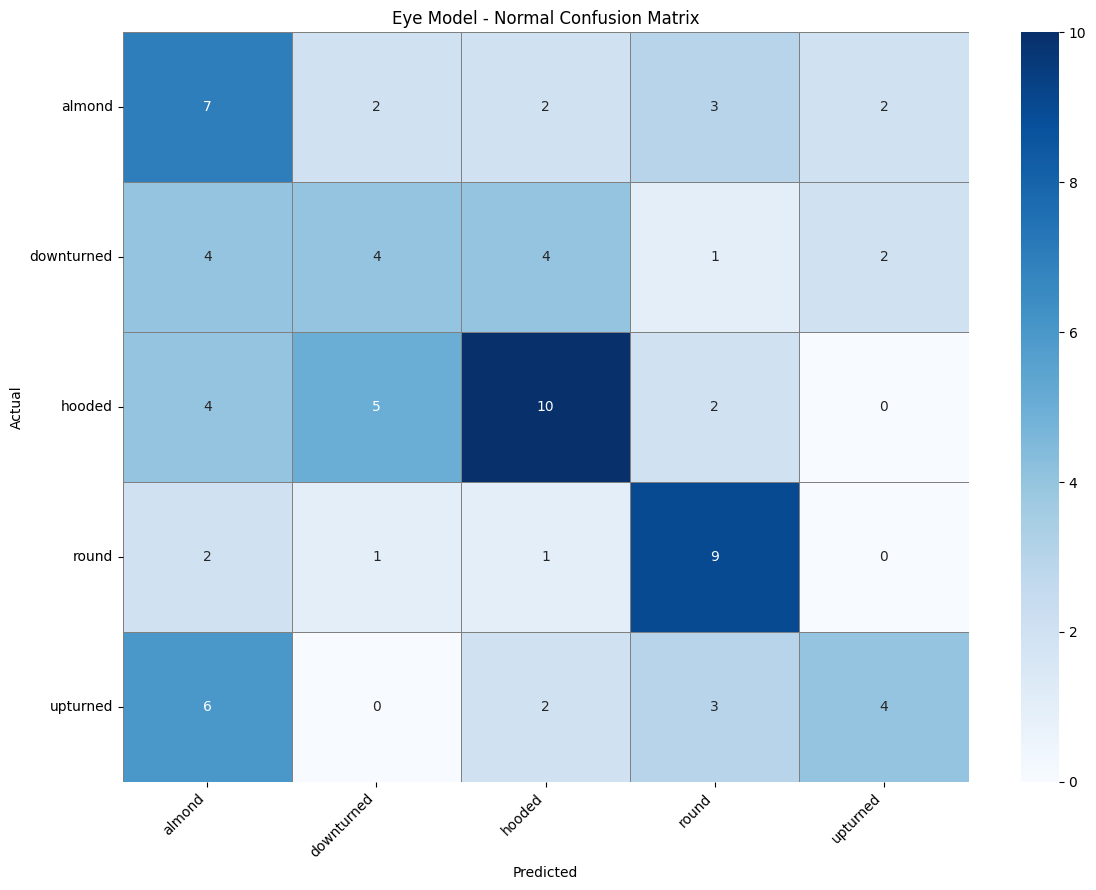


Eye Model - TTA Evaluation (x5)
Accuracy       : 0.4375 (43.75%)
Macro F1-score : 0.4298

Classification Report:
              precision    recall  f1-score   support

      almond       0.38      0.38      0.38        16
  downturned       0.40      0.40      0.40        15
      hooded       0.46      0.52      0.49        21
       round       0.50      0.62      0.55        13
    upturned       0.44      0.27      0.33        15

    accuracy                           0.44        80
   macro avg       0.44      0.44      0.43        80
weighted avg       0.43      0.44      0.43        80


Raw Confusion Matrix - Eye Model - TTA Confusion Matrix (x5):
[[ 6  1  5  2  2]
 [ 2  6  5  1  1]
 [ 3  3 11  3  1]
 [ 3  1  0  8  1]
 [ 2  4  3  2  4]]


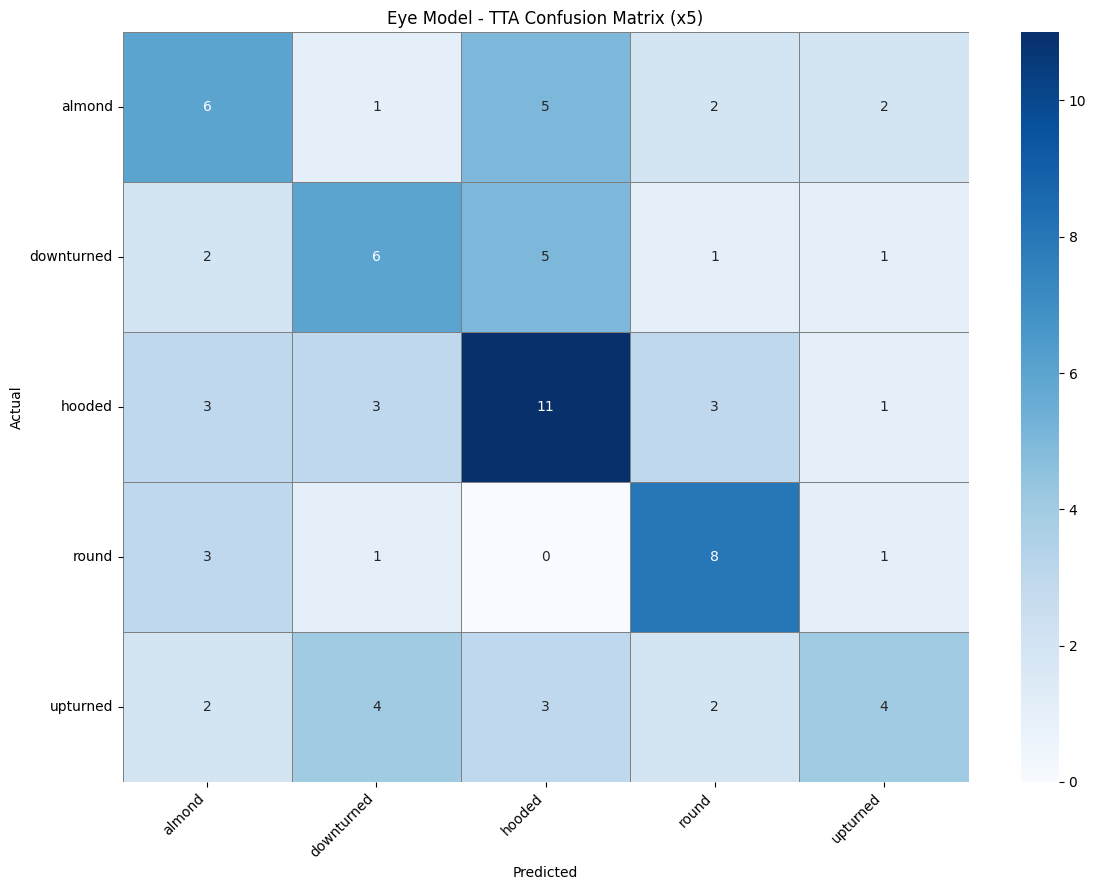


SUMMARY
Face Normal Acc: 73.2% | F1: 0.731
Face TTA Acc   : 79.6% | F1: 0.797
Eye Normal Acc : 42.5% | F1: 0.417
Eye TTA Acc    : 43.8% | F1: 0.430


In [20]:
def predict_normal(model, dataset):
    all_probs, all_labels = [], []

    for images, labels in dataset:
        probs = model(images, training=False).numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())

    all_probs  = np.concatenate(all_probs, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    return np.argmax(all_probs, axis=1), all_labels, all_probs


def tta_predict(model, dataset, n_tta=5):
    tta_aug = keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
        layers.RandomBrightness(0.15),
    ])

    all_probs, all_labels = [], []

    for images, labels in dataset:
        all_labels.append(labels.numpy())

        probs = model(images, training=False).numpy()

        for _ in range(n_tta - 1):
            aug_images = tta_aug(images, training=True)
            probs += model(aug_images, training=False).numpy()

        all_probs.append(probs / n_tta)

    all_probs  = np.concatenate(all_probs, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    return np.argmax(all_probs, axis=1), all_labels, all_probs


def plot_confusion_matrix(true_cls, pred_cls, idx2label, title):
    labels = sorted(idx2label.keys())
    class_names = [idx2label[i] for i in labels]

    cm = confusion_matrix(true_cls, pred_cls, labels=labels)

    print(f"\nRaw Confusion Matrix - {title}:")
    print(cm)

    annot = cm.astype(str)

    fig, ax = plt.subplots(figsize=(12, 9))

    sns.heatmap(
        cm,
        annot=annot,
        fmt='',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=0.5,
        linecolor='gray',
        cbar=True,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


def print_metrics(true_cls, pred_cls, idx2label, title):
    labels = sorted(idx2label.keys())
    class_names = [idx2label[i] for i in labels]

    acc = np.mean(pred_cls == true_cls)
    f1 = f1_score(
        true_cls,
        pred_cls,
        average='macro',
        labels=labels,
        zero_division=0
    )

    print(f'\n{"="*55}')
    print(title)
    print(f'{"="*55}')
    print(f'Accuracy       : {acc:.4f} ({acc*100:.2f}%)')
    print(f'Macro F1-score : {f1:.4f}')

    print('\nClassification Report:')
    print(classification_report(
        true_cls,
        pred_cls,
        labels=labels,
        target_names=class_names,
        zero_division=0
    ))

    return acc, f1


def full_evaluation(model, test_ds, idx2label, title='Model', n_tta=5):
    # Normal prediction
    normal_pred, true_cls, _ = predict_normal(model, test_ds)

    normal_acc, normal_f1 = print_metrics(
        true_cls,
        normal_pred,
        idx2label,
        f'{title} - NORMAL Evaluation'
    )

    plot_confusion_matrix(
        true_cls,
        normal_pred,
        idx2label,
        f'{title} - Normal Confusion Matrix'
    )

    # TTA prediction
    tta_pred, true_cls, _ = tta_predict(model, test_ds, n_tta=n_tta)

    tta_acc, tta_f1 = print_metrics(
        true_cls,
        tta_pred,
        idx2label,
        f'{title} - TTA Evaluation (x{n_tta})'
    )

    plot_confusion_matrix(
        true_cls,
        tta_pred,
        idx2label,
        f'{title} - TTA Confusion Matrix (x{n_tta})'
    )

    return normal_acc, normal_f1, tta_acc, tta_f1, normal_pred, tta_pred, true_cls


face_normal_acc, face_normal_f1, face_tta_acc, face_tta_f1, face_normal_preds, face_tta_preds, face_true = full_evaluation(
    face_model,
    face_test_ds,
    face_idx2label,
    'Face Model',
    n_tta=5
)

eye_normal_acc, eye_normal_f1, eye_tta_acc, eye_tta_f1, eye_normal_preds, eye_tta_preds, eye_true = full_evaluation(
    eye_model,
    eye_test_ds,
    eye_idx2label,
    'Eye Model',
    n_tta=5
)


print(
    f'\nSUMMARY'
    f'\nFace Normal Acc: {face_normal_acc*100:.1f}% | F1: {face_normal_f1:.3f}'
    f'\nFace TTA Acc   : {face_tta_acc*100:.1f}% | F1: {face_tta_f1:.3f}'
    f'\nEye Normal Acc : {eye_normal_acc*100:.1f}% | F1: {eye_normal_f1:.3f}'
    f'\nEye TTA Acc    : {eye_tta_acc*100:.1f}% | F1: {eye_tta_f1:.3f}'
)

Face Grad-CAM (5 test images):


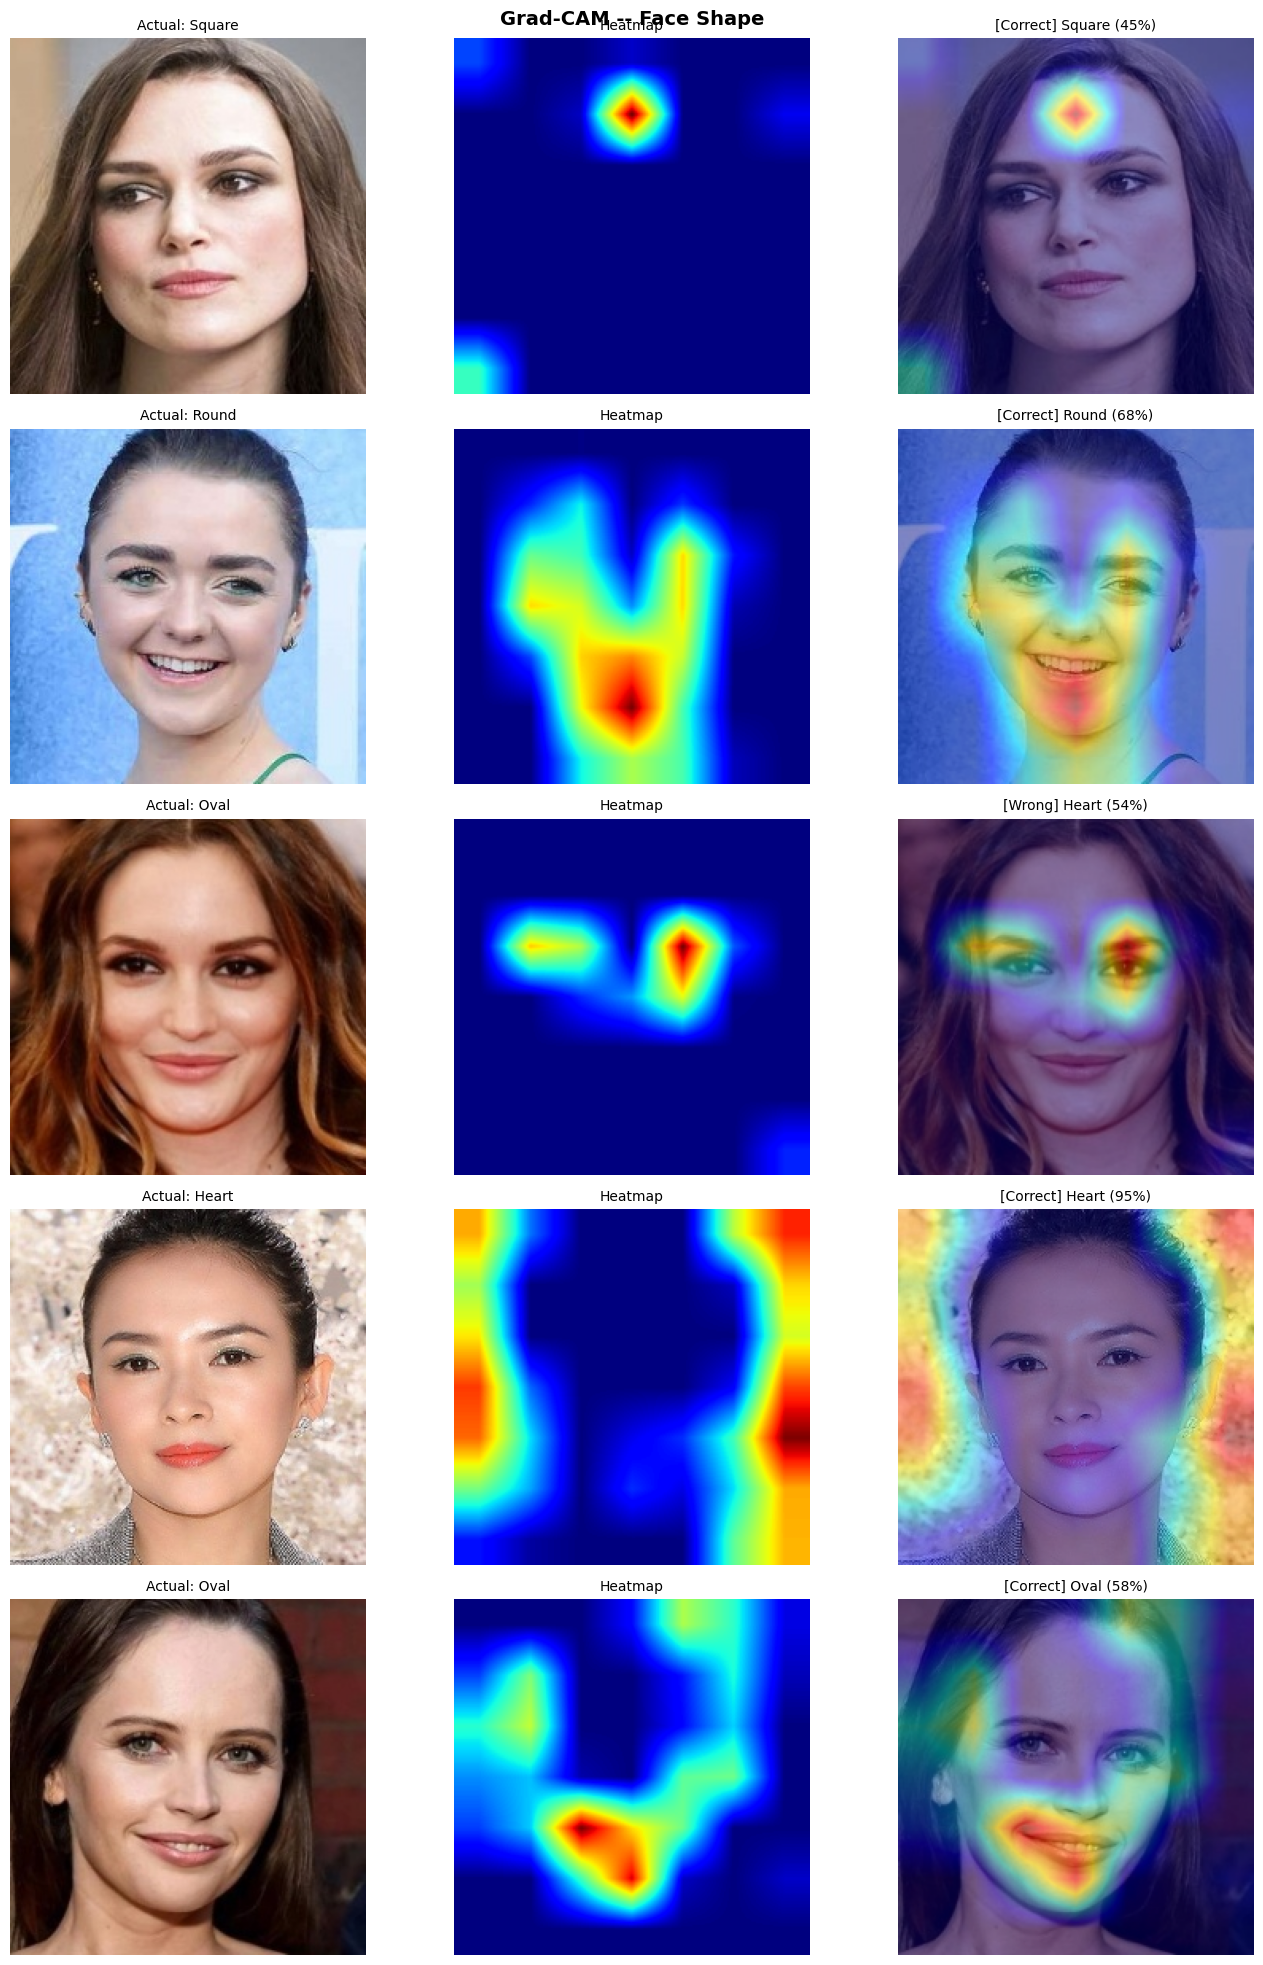


Eye Grad-CAM (5 test images):


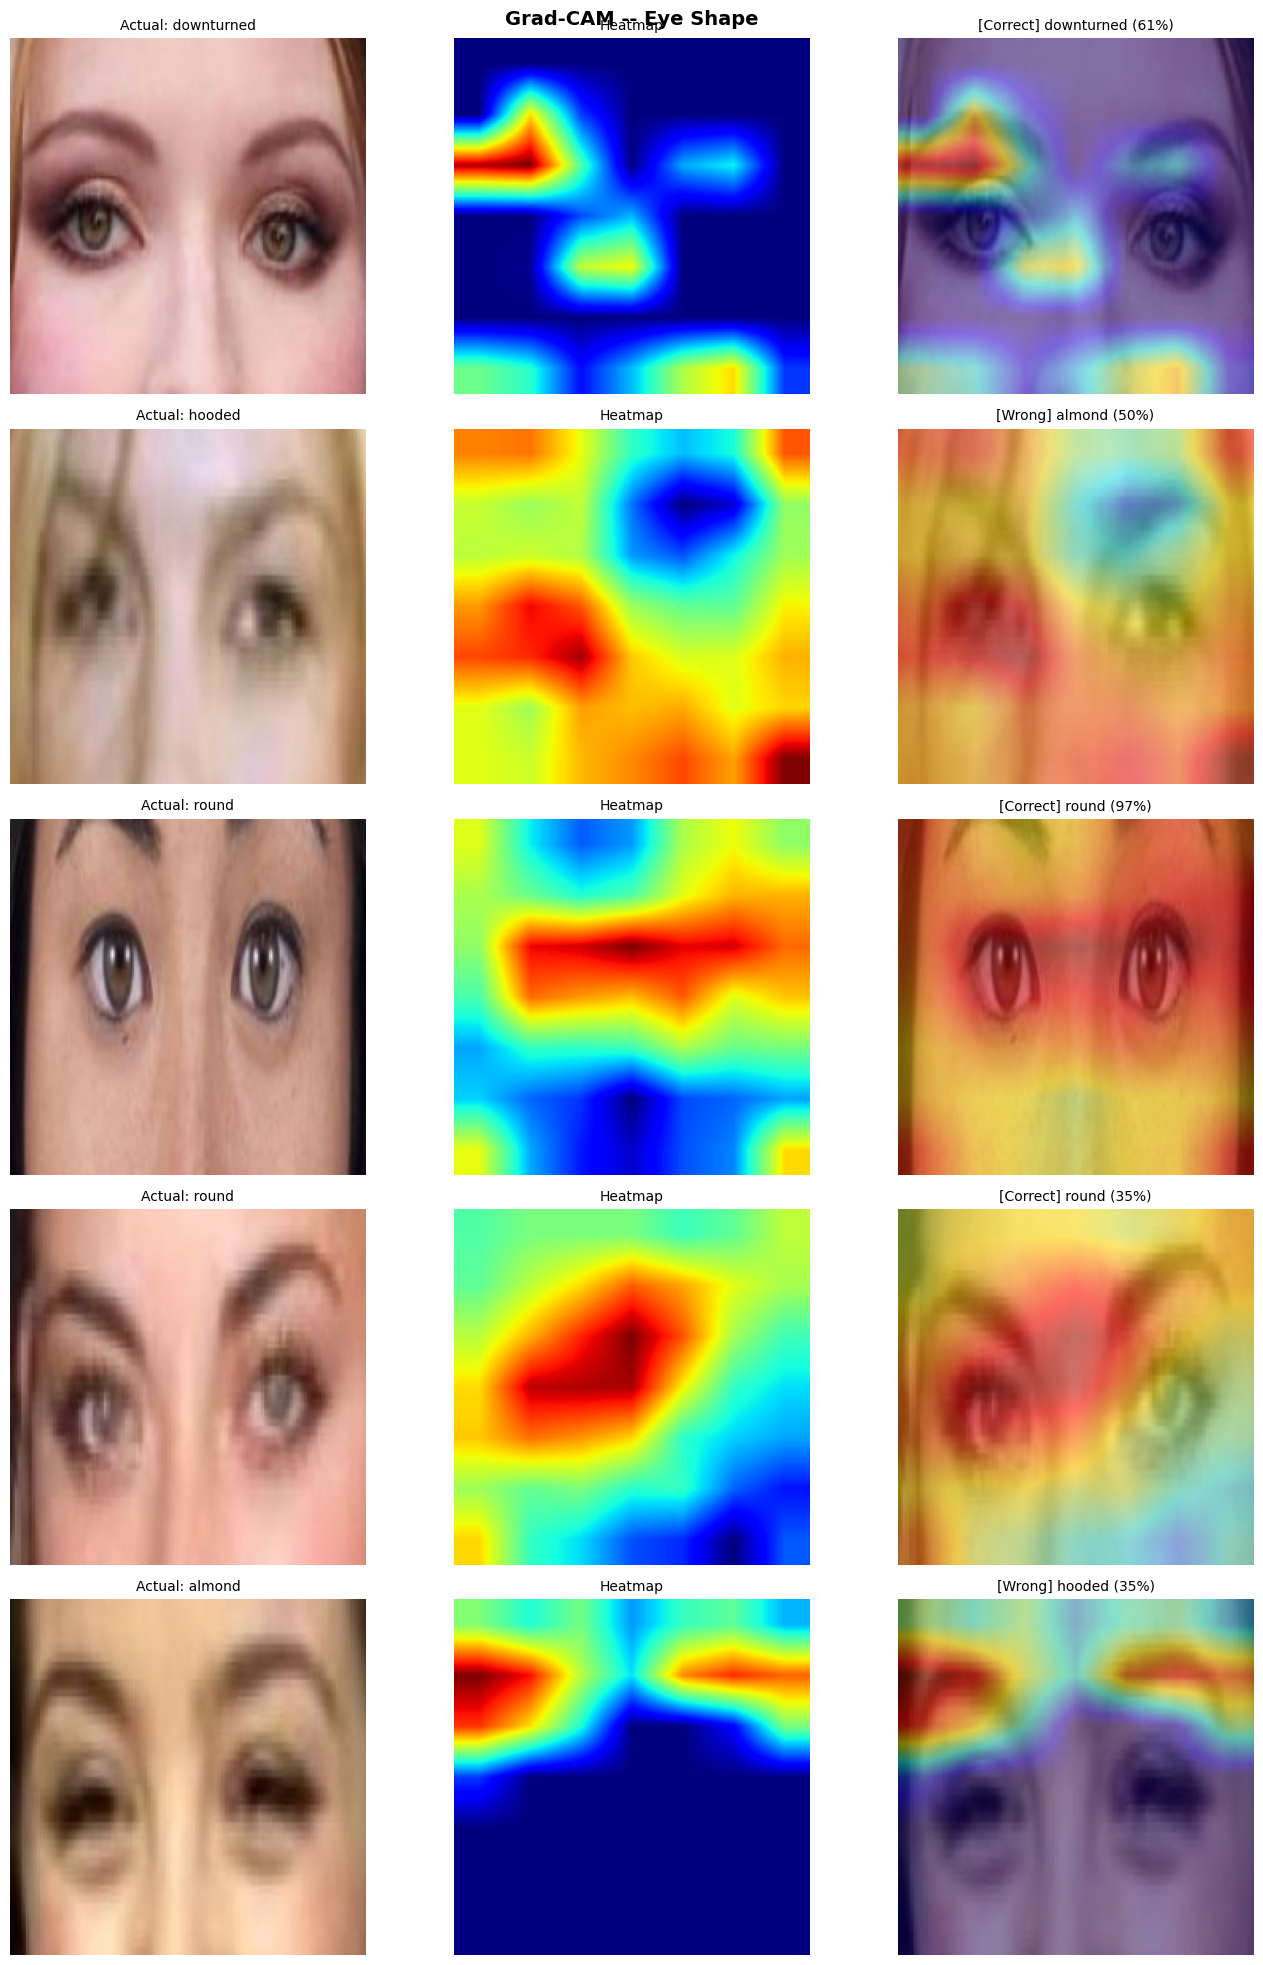

In [21]:
GRADCAM_LAYER = 'top_conv'  # last conv layer in EfficientNetB0

def get_gradcam(model, img_tensor, layer_name):
    grad_model = models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_tensor, training=False)
        tape.watch(conv_out)
        pred_idx = tf.argmax(preds[0])
        loss     = preds[:, pred_idx]
    grads   = tape.gradient(loss, conv_out)
    pooled  = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_sum(conv_out[0] * pooled, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    mx      = tf.reduce_max(heatmap)
    if mx > 0:
        heatmap = heatmap / mx
    return heatmap.numpy()


def show_gradcam_grid(model, test_dir, idx2label, n=5, title=''):
    all_paths = (list(Path(test_dir).rglob('*.jpg')) +
                 list(Path(test_dir).rglob('*.jpeg')) +
                 list(Path(test_dir).rglob('*.png')))
    if not all_paths:
        print(f'No images in {test_dir}'); return
    samples = random.sample(all_paths, min(n, len(all_paths)))
    fig, axes = plt.subplots(n, 3, figsize=(14, n * 4))
    if n == 1: axes = [axes]
    fig.suptitle(f'Grad-CAM -- {title}', fontsize=14, fontweight='bold')
    for i, img_path in enumerate(samples):
        actual = img_path.parent.name
        raw    = cv2.imread(str(img_path))
        if raw is None: continue
        rgb    = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
        resized = cv2.resize(rgb, IMG_SIZE).astype('float32')
        batch   = tf.expand_dims(resized, 0)
        probs   = model(batch, training=False).numpy()[0]
        pred_idx  = int(np.argmax(probs))
        pred_lbl  = idx2label[pred_idx]
        conf      = float(probs[pred_idx])
        correct   = 'Correct' if pred_lbl.lower() == actual.lower() else 'Wrong'
        heat    = get_gradcam(model, batch, GRADCAM_LAYER)
        heat_up = cv2.resize(heat, IMG_SIZE)
        heat_col = cv2.applyColorMap((heat_up * 255).astype(np.uint8), cv2.COLORMAP_JET)
        heat_col = cv2.cvtColor(heat_col, cv2.COLOR_BGR2RGB)
        overlay  = (0.55 * resized + 0.45 * heat_col).clip(0, 255).astype(np.uint8)
        axes[i][0].imshow(resized.astype(np.uint8))
        axes[i][0].set_title(f'Actual: {actual}', fontsize=10); axes[i][0].axis('off')
        axes[i][1].imshow(heat_up, cmap='jet')
        axes[i][1].set_title('Heatmap', fontsize=10); axes[i][1].axis('off')
        axes[i][2].imshow(overlay)
        axes[i][2].set_title(f'[{correct}] {pred_lbl} ({conf:.0%})', fontsize=10)
        axes[i][2].axis('off')
    plt.tight_layout(); plt.show()


print('Face Grad-CAM (5 test images):')
show_gradcam_grid(face_model, 'processed_face/test', face_idx2label, n=5, title='Face Shape')
print('\nEye Grad-CAM (5 test images):')
show_gradcam_grid(eye_model, 'processed_eye/test', eye_idx2label, n=5, title='Eye Shape')


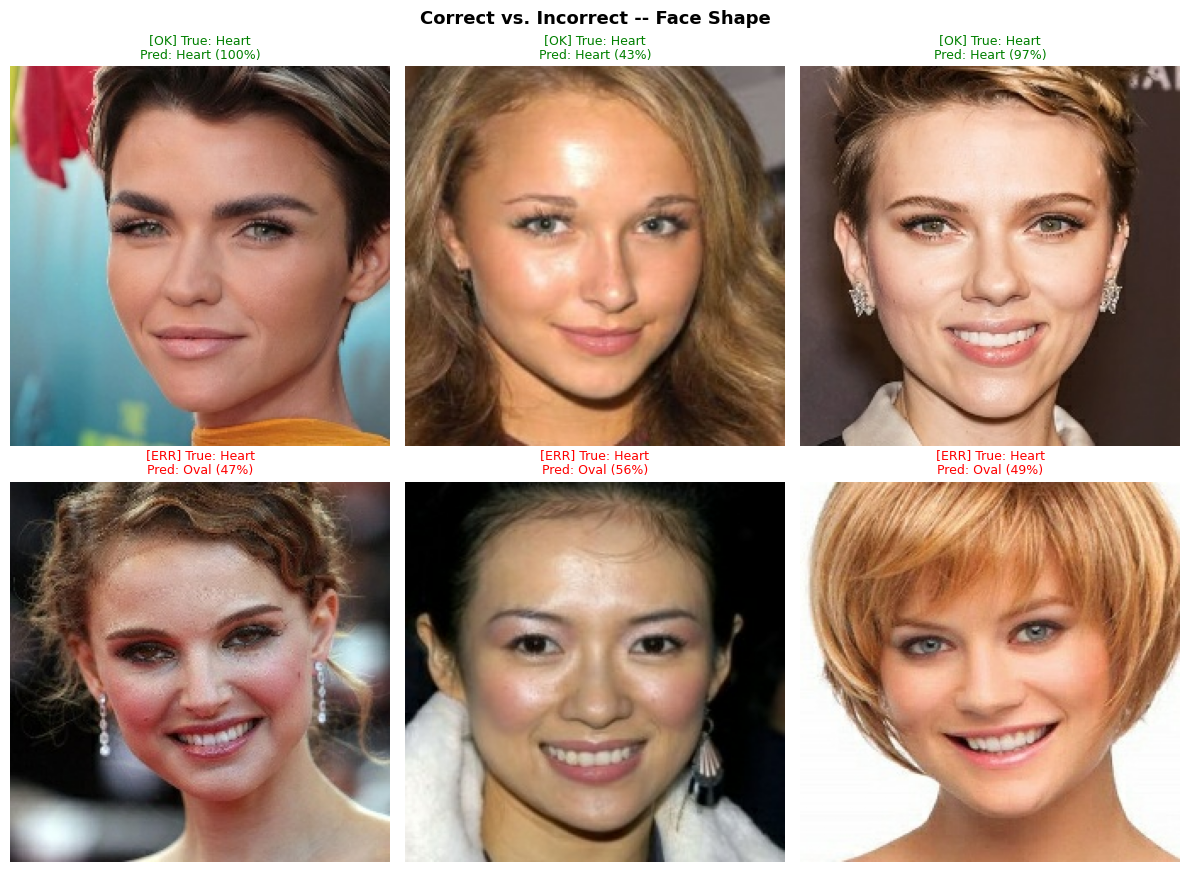

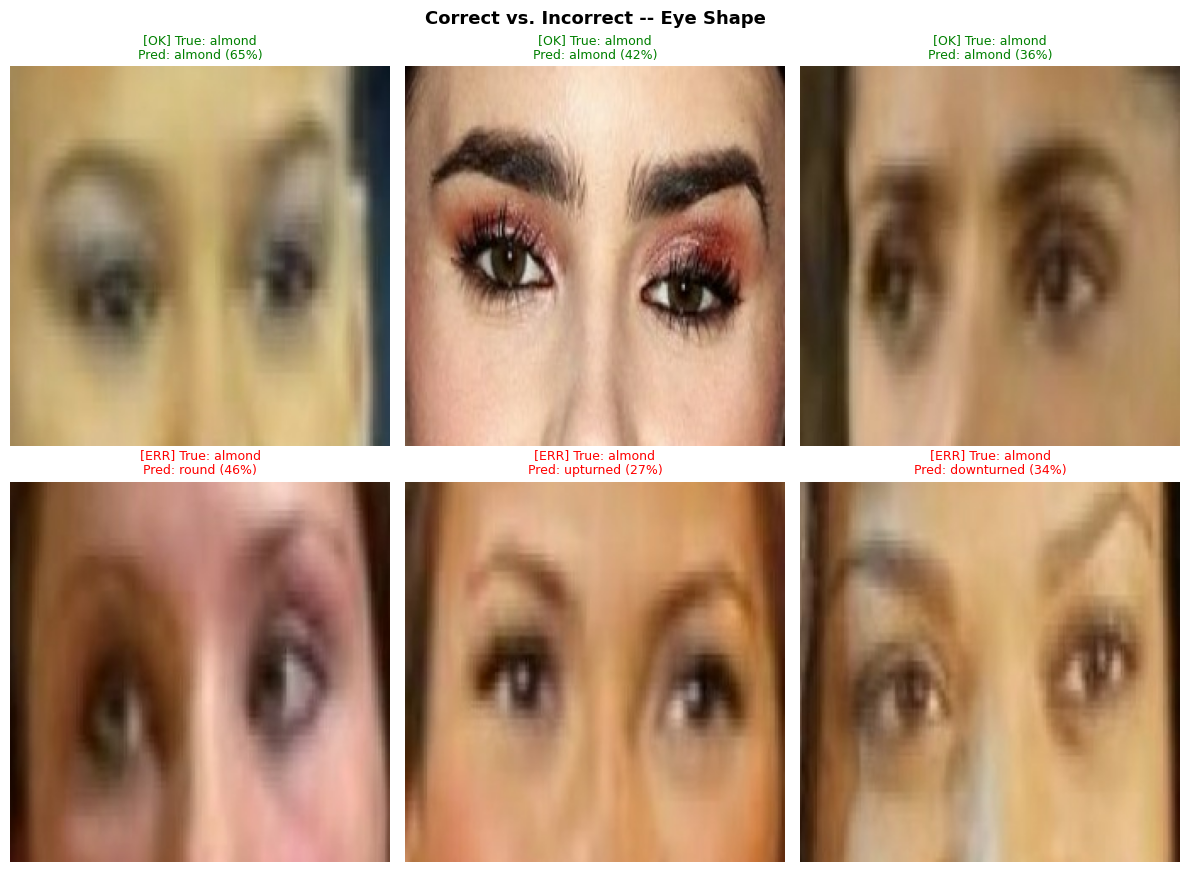

In [22]:
def show_correct_incorrect(model, test_ds, idx2label, title='', n_each=3):
    correct_ex, wrong_ex = [], []
    for images, labels in test_ds:
        preds = model(images, training=False).numpy()
        pred_cls = np.argmax(preds, axis=1)
        for i in range(len(labels)):
            true, pred = int(labels[i]), int(pred_cls[i])
            entry = (images[i].numpy(), true, pred, float(preds[i][pred]))
            if true == pred and len(correct_ex) < n_each:
                correct_ex.append(entry)
            elif true != pred and len(wrong_ex) < n_each:
                wrong_ex.append(entry)
        if len(correct_ex) >= n_each and len(wrong_ex) >= n_each:
            break
    fig, axes = plt.subplots(2, max(n_each, 1), figsize=(n_each * 4, 9))
    fig.suptitle(f'Correct vs. Incorrect -- {title}', fontsize=13, fontweight='bold')
    for col, (img, true, pred, conf) in enumerate(correct_ex[:n_each]):
        disp = (img / 255.0).clip(0, 1) if img.max() > 1.5 else img
        axes[0][col].imshow(disp)
        axes[0][col].set_title(f'[OK] True: {idx2label[true]}\nPred: {idx2label[pred]} ({conf:.0%})',
                               color='green', fontsize=9)
        axes[0][col].axis('off')
    for col, (img, true, pred, conf) in enumerate(wrong_ex[:n_each]):
        disp = (img / 255.0).clip(0, 1) if img.max() > 1.5 else img
        axes[1][col].imshow(disp)
        axes[1][col].set_title(f'[ERR] True: {idx2label[true]}\nPred: {idx2label[pred]} ({conf:.0%})',
                               color='red', fontsize=9)
        axes[1][col].axis('off')
    plt.tight_layout(); plt.show()


show_correct_incorrect(face_model, face_test_ds, face_idx2label, 'Face Shape', n_each=3)
show_correct_incorrect(eye_model,  eye_test_ds,  eye_idx2label,  'Eye Shape',  n_each=3)


## Ethics and Responsible AI

### Consent and Privacy
All models are trained on publicly available, open-source datasets (Kaggle Face Shape Dataset and Roboflow Eye Shapes Dataset) that permit educational use. No user images are stored or transmitted; all inference is performed locally within the notebook environment.

### Prohibited Capabilities
This system does **not** and **must not** perform identity recognition (face recognition), gender classification, or ethnic inference. Predictions are strictly limited to geometric facial attributes (face shape and eye shape) which have no direct link to personal identity.

### Dataset Bias and Fairness
- The Kaggle face shape dataset is predominantly generated/synthetic, which reduces demographic over-representation but may not reflect real-world variation in skin tone, age, or facial hair.
- The Roboflow eye dataset is collected from real images; class imbalance is mitigated through class-weighted loss and balanced augmentation.
- Future work should audit model accuracy stratified by demographic subgroups using a balanced real-world benchmark (e.g. FairFace).

### Limitations
1. Haar cascade face detection may fail on non-frontal or partially occluded faces; a centre-crop fallback is used.
2. Style recommendations are based on conventional beauty standards and may not be culturally inclusive.
3. EfficientNetB0 trained on small datasets may exhibit overconfidence on out-of-distribution images.
4. The eye preprocessing uses direct resize from pre-cropped Roboflow images; errors in source annotations propagate directly.

### Recommended Mitigations for Production Deployment
- Add a confidence threshold below which no recommendation is issued.
- Conduct a demographic bias audit using FairFace or CelebA annotations.
- Provide user-facing explainability (Grad-CAM overlays already implemented).
- Obtain explicit informed consent before processing any real face image.
